# Traffic Flow Simulation
**Discrete-time, section-based congestion model on a directed road network.**

Vehicles are spawned from multiple origins via a Poisson process, routed on shortest paths, and advance section-by-section through each edge. Congestion is detected when ≥2/3 of an edge's sections are occupied.

## 1 · Imports

In [1]:
import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

## 2 · Road Network

In [2]:
G = nx.DiGraph()

# (u, v, free_flow_time [ticks], capacity [veh/tick])
EDGES = [
    ("A", "B", 3, 2),
    ("B", "C", 4, 2),
    ("C", "D", 3, 1),
    ("A", "D", 5, 2),
    ("B", "A", 3, 2),
    ("C", "A", 4, 1),
    ("D", "A", 3, 2),
    ("D", "B", 2, 1),
]

for u, v, fft, cap in EDGES:
    G.add_edge(u, v, free_flow_time=fft, capacity=cap)

print("Nodes:", list(G.nodes()))
print("Edges:", list(G.edges()))

Nodes: ['A', 'B', 'C', 'D']
Edges: [('A', 'B'), ('A', 'D'), ('B', 'C'), ('B', 'A'), ('C', 'D'), ('C', 'A'), ('D', 'A'), ('D', 'B')]


## 3 · Simulation Parameters

In [3]:
TICKS        = 200       # total simulation time steps
ARRIVAL_RATE = 0.5       # Poisson λ per origin per tick (approximated as Bernoulli)
ORIGINS      = list(G.nodes())  # all nodes act as origins
RANDOM_SEED  = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

## 4 · State Initialisation

In [4]:
# Number of sections per edge (= free-flow travel time)
edge_sections = {(u, v): G[u][v]["free_flow_time"] for u, v in G.edges()}

# Occupancy: edge -> section_index -> set of vehicle IDs
edge_occupancy = {
    edge: {s: set() for s in range(edge_sections[edge])}
    for edge in G.edges()
}

# History for analytics
edge_occupancy_history = {edge: [] for edge in G.edges()}
congestion_counts      = []

print("Sections per edge:")
for e, n in edge_sections.items():
    print(f"  {e}: {n} sections")

Sections per edge:
  ('A', 'B'): 3 sections
  ('A', 'D'): 5 sections
  ('B', 'C'): 4 sections
  ('B', 'A'): 3 sections
  ('C', 'D'): 3 sections
  ('C', 'A'): 4 sections
  ('D', 'A'): 3 sections
  ('D', 'B'): 2 sections


## 5 · Vehicle Class

In [5]:
class Vehicle:
    """Represents a single vehicle travelling along a pre-computed shortest path."""

    _id_counter: int = 0

    def __init__(self, origin: str, dest: str, start_tick: int) -> None:
        Vehicle._id_counter += 1
        self.id            = Vehicle._id_counter
        self.origin        = origin
        self.dest          = dest
        self.path          = nx.shortest_path(G, origin, dest, weight="free_flow_time")
        self.edge_index    = 0       # index into path (current edge = path[i] -> path[i+1])
        self.current_section = 0     # section within current edge
        self.start_tick    = start_tick
        self.end_tick: int | None = None

    def current_edge(self):
        """Return the edge tuple the vehicle is currently on, or None if done."""
        if self.edge_index >= len(self.path) - 1:
            return None
        return (self.path[self.edge_index], self.path[self.edge_index + 1])

    def __repr__(self) -> str:
        return f"V{self.id}({self.origin}->{self.dest})"

## 6 · Simulation Loop

Each tick:
1. **Spawn** new vehicles (Bernoulli approximation of Poisson arrivals)
2. **Advance** every active vehicle one section forward
3. **Detect** congested edges (≥ 2/3 sections occupied)
4. **Record** occupancy history

In [6]:
active: list[Vehicle]    = []
completed: list[Vehicle] = []

CONGESTION_THRESHOLD = 2 / 3   # fraction of sections occupied → congested

for tick in range(TICKS):

    # ── 1. Spawn new vehicles ──────────────────────────────────────────────
    for origin in ORIGINS:
        if np.random.rand() < ARRIVAL_RATE:
            dest = random.choice([n for n in ORIGINS if n != origin])
            v = Vehicle(origin, dest, tick)
            active.append(v)
            first_edge = (v.path[0], v.path[1])
            edge_occupancy[first_edge][0].add(v.id)

    # ── 2. Advance active vehicles ─────────────────────────────────────────
    for v in list(active):
        edge = v.current_edge()
        if edge is None:
            continue
        u, w = edge
        total_sections = edge_sections[edge]

        # Remove from current section
        if v.current_section > 0:
            edge_occupancy[edge][v.current_section - 1].discard(v.id)

        if v.current_section < total_sections - 1:
            # Move to next section within same edge
            v.current_section += 1
            edge_occupancy[edge][v.current_section].add(v.id)
        else:
            # Reached end of this edge
            edge_occupancy[edge][v.current_section].discard(v.id)
            v.edge_index    += 1
            v.current_section = 0

            if v.edge_index >= len(v.path) - 1:
                # Trip complete
                v.end_tick = tick
                completed.append(v)
                active.remove(v)
            else:
                # Enter first section of next edge
                next_edge = v.current_edge()
                edge_occupancy[next_edge][0].add(v.id)

    # ── 3. Detect congestion ───────────────────────────────────────────────
    congested_edges = [
        edge
        for edge, sections in edge_occupancy.items()
        if sum(1 for s in sections.values() if s) / edge_sections[edge]
           >= CONGESTION_THRESHOLD
    ]
    congestion_counts.append(len(congested_edges))

    # ── 4. Record per-edge occupancy ───────────────────────────────────────
    for edge, sections in edge_occupancy.items():
        total_veh = sum(len(s) for s in sections.values())
        edge_occupancy_history[edge].append(total_veh)

print(f"Simulation complete. {TICKS} ticks run.")
print(f"Vehicles spawned:    {Vehicle._id_counter}")
print(f"Vehicles completed:  {len(completed)}")
print(f"Vehicles still en-route: {len(active)}")

Simulation complete. 200 ticks run.
Vehicles spawned:    392
Vehicles completed:  389
Vehicles still en-route: 3


## 7 · Summary Statistics

In [7]:
travel_times = [v.end_tick - v.start_tick for v in completed]

print("=" * 50)
print("TRAVEL TIME STATISTICS")
print("=" * 50)
if travel_times:
    print(f"  Mean   : {np.mean(travel_times):.2f} ticks")
    print(f"  Median : {np.median(travel_times):.2f} ticks")
    print(f"  Std dev: {np.std(travel_times):.2f} ticks")
    print(f"  P95    : {np.percentile(travel_times, 95):.2f} ticks")
    print(f"  Max    : {np.max(travel_times):.2f} ticks")

print()
print("=" * 50)
print("EDGE UTILISATION  (avg vehicles / capacity)")
print("=" * 50)
for edge, history in edge_occupancy_history.items():
    cap = G[edge[0]][edge[1]]["capacity"]
    avg_load = np.mean(history) if history else 0.0
    util     = avg_load / cap
    bar      = "█" * int(util * 20)
    print(f"  {edge}  util={util:.2f}  [{bar:<20}]")

print()
print("=" * 50)
print("CONGESTION SUMMARY")
print("=" * 50)
print(f"  Avg congested edges / tick : {np.mean(congestion_counts):.2f}")
print(f"  Max congested edges / tick : {np.max(congestion_counts)}")
print(f"  Ticks with any congestion  : {sum(1 for c in congestion_counts if c > 0)}")
print(f"  Congestion rate            : {sum(1 for c in congestion_counts if c > 0) / TICKS * 100:.1f}%")

TRAVEL TIME STATISTICS
  Mean   : 3.36 ticks
  Median : 3.00 ticks
  Std dev: 1.56 ticks
  P95    : 6.00 ticks
  Max    : 6.00 ticks

EDGE UTILISATION  (avg vehicles / capacity)
  ('A', 'B')  util=0.65  [█████████████       ]
  ('A', 'D')  util=0.70  [██████████████      ]
  ('B', 'C')  util=1.97  [███████████████████████████████████████]
  ('B', 'A')  util=0.34  [██████              ]
  ('C', 'D')  util=2.23  [████████████████████████████████████████████]
  ('C', 'A')  util=1.29  [█████████████████████████]
  ('D', 'A')  util=0.35  [███████             ]
  ('D', 'B')  util=0.99  [███████████████████ ]

CONGESTION SUMMARY
  Avg congested edges / tick : 3.06
  Max congested edges / tick : 8
  Ticks with any congestion  : 198
  Congestion rate            : 99.0%


## 8 · Visualisations

In [17]:
import os

output_dir = os.path.join(os.getcwd(), "outputs")
os.makedirs(output_dir, exist_ok=True)

print("cwd:", os.getcwd())
print("output_dir:", output_dir)
print("exists output_dir:", os.path.exists(output_dir))

cwd: d:\programming\non library stuff\Projects\non research\software based\non hackathon\vehicle simulation and rerouting
output_dir: d:\programming\non library stuff\Projects\non research\software based\non hackathon\vehicle simulation and rerouting\outputs
exists output_dir: True


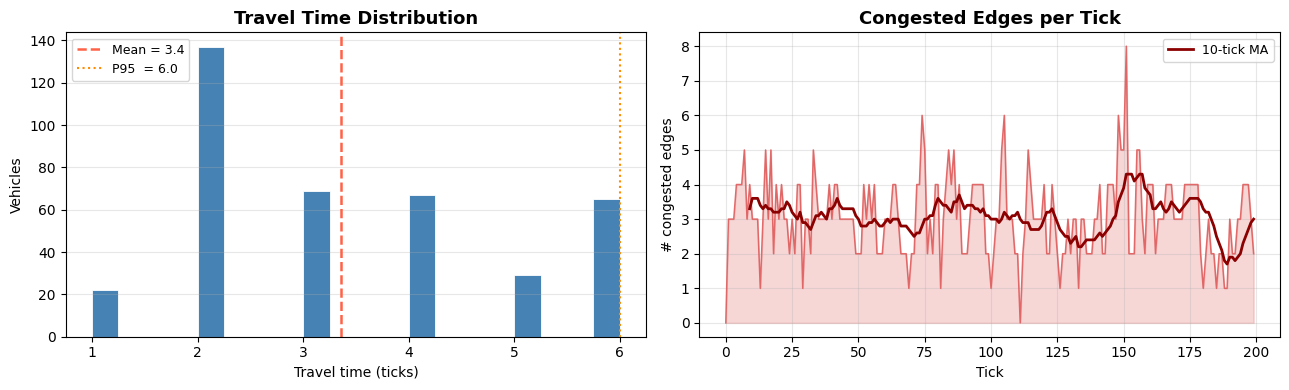

Saved → traffic_sim_plots.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Travel time distribution ─────────────────────────────────────────────
ax = axes[0]
ax.hist(travel_times, bins=20, color="steelblue", edgecolor="white", linewidth=0.6)
ax.axvline(np.mean(travel_times), color="tomato", linewidth=1.8, linestyle="--", label=f"Mean = {np.mean(travel_times):.1f}")
ax.axvline(np.percentile(travel_times, 95), color="darkorange", linewidth=1.5, linestyle=":", label=f"P95  = {np.percentile(travel_times, 95):.1f}")
ax.set_title("Travel Time Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Travel time (ticks)")
ax.set_ylabel("Vehicles")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# ── Congestion over time ─────────────────────────────────────────────────
ax = axes[1]
ax.plot(congestion_counts, color="#e05c5c", linewidth=1.1, alpha=0.9)
ax.fill_between(range(TICKS), congestion_counts, alpha=0.25, color="#e05c5c")
window = 10
smoothed = np.convolve(congestion_counts, np.ones(window) / window, mode="valid")
ax.plot(range(window - 1, TICKS), smoothed, color="darkred", linewidth=2, label=f"{window}-tick MA")
ax.set_title("Congested Edges per Tick", fontsize=13, fontweight="bold")
ax.set_xlabel("Tick")
ax.set_ylabel("# congested edges")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "traffic_sim_plots.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → traffic_sim_plots.png")


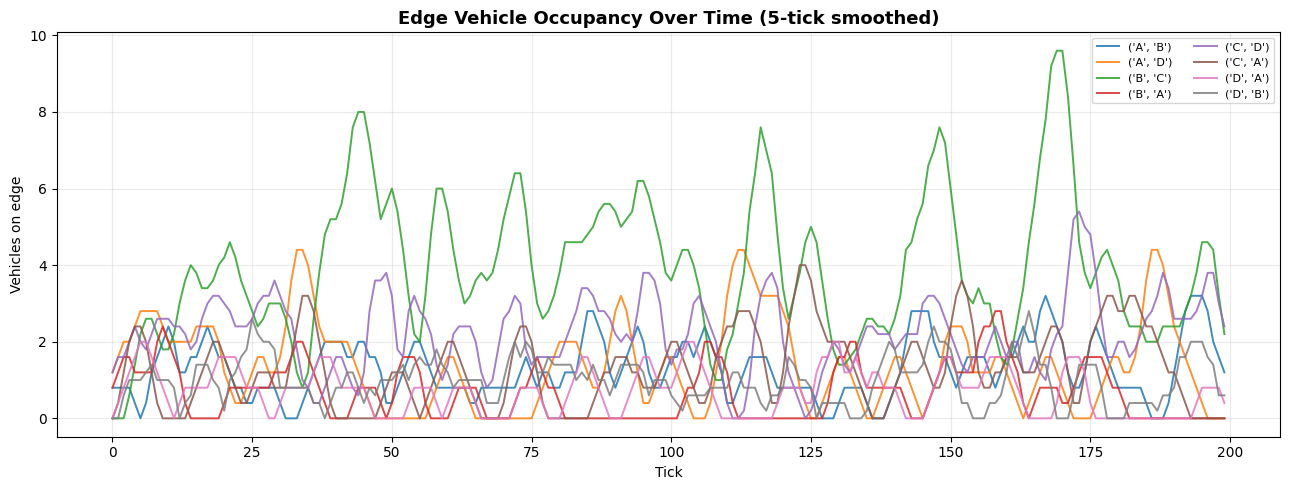

Saved → edge_occupancy.png


In [26]:
fig, ax = plt.subplots(figsize=(13, 5))

cmap   = plt.get_cmap("tab10")
edges  = list(edge_occupancy_history.keys())

for i, edge in enumerate(edges):
    hist = edge_occupancy_history[edge]
    smoothed = np.convolve(hist, np.ones(5) / 5, mode="same")
    ax.plot(smoothed, label=str(edge), color=cmap(i % 10), linewidth=1.4, alpha=0.85)

ax.set_title("Edge Vehicle Occupancy Over Time (5-tick smoothed)", fontsize=13, fontweight="bold")
ax.set_xlabel("Tick")
ax.set_ylabel("Vehicles on edge")
ax.legend(ncol=2, fontsize=8, loc="upper right")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "edge_occupancy.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → edge_occupancy.png")

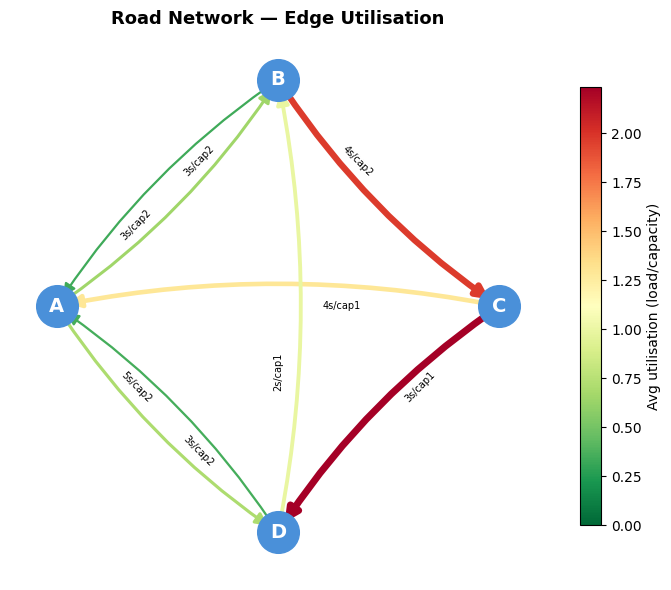

Saved → network_utilisation.png


In [27]:
fig, ax = plt.subplots(figsize=(7, 6))

pos = {"A": (0, 1), "B": (1, 2), "C": (2, 1), "D": (1, 0)}

# Colour edges by average utilisation
edge_utils = [
    np.mean(edge_occupancy_history[e]) / G[e[0]][e[1]]["capacity"]
    for e in G.edges()
]
max_util = max(edge_utils) if edge_utils else 1
edge_colors = [plt.cm.RdYlGn_r(u / max_util) for u in edge_utils]
edge_widths = [1 + 4 * (u / max_util) for u in edge_utils]

nx.draw_networkx_nodes(G, pos, ax=ax, node_size=900, node_color="#4a90d9")
nx.draw_networkx_labels(G, pos, ax=ax, font_color="white", font_weight="bold", font_size=14)
nx.draw_networkx_edges(
    G, pos, ax=ax,
    edge_color=edge_colors,
    width=edge_widths,
    connectionstyle="arc3,rad=0.1",
    arrows=True,
    arrowsize=18,
)

# Edge labels: (FFT / cap)
edge_labels = {(u, v): f"{G[u][v]['free_flow_time']}s/cap{G[u][v]['capacity']}" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels, ax=ax, font_size=7, label_pos=0.35)

sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=plt.Normalize(0, max_util))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Avg utilisation (load/capacity)", shrink=0.8)

ax.set_title("Road Network — Edge Utilisation", fontsize=13, fontweight="bold")
ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "network_utilisation.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → network_utilisation.png")